# Uncertainty-Aware Prototype-Guided Routing with LoRA Experts for Task-Agnostic Continual Learning

This notebook implements a task-agnostic continual learning system using a frozen ViT backbone, LoRA expert adapters, entropy-aware prototype-guided routing, and expert-specific replay buffers.

### How to run
1. Open this notebook in Google Colab with GPU enabled.
2. Run the setup cell to mount Google Drive and install dependencies.
3. Review the configuration cell. Keep `debug=False` for the full reported experiment, or set `debug=True` for a quick smoke test.
4. Run the experiment cells, then generate plots and final summaries.

### Main outputs
- Accuracy and forgetting curves.
- Routing entropy and selected-expert statistics.
- Expert utilization and class-to-expert heatmaps.
- Compute-savings comparison against static top-3 routing.

### Notes
- No private Hugging Face token is stored in this notebook. If authentication is needed, add `HF_TOKEN` through Colab Secrets.
- The output directory is controlled by `config.out_dir`.


In [1]:
# Mount Google Drive when running in Colab. This keeps outputs and model caches persistent.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Google Drive mount skipped; likely not running in Colab:", str(e)[:120])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment Setup and Imports
This cell installs required packages, mounts Google Drive when available, sets persistent cache directories, and imports dependencies. Hugging Face authentication is read from Colab Secrets only; no token is stored in the notebook.

In [2]:
!pip -q install timm huggingface_hub

import os
os.environ.setdefault("HF_HOME", "/content/drive/MyDrive/CLMM/hf_cache")
os.environ.setdefault("TORCH_HOME", "/content/drive/MyDrive/CLMM/torch_cache")

# Optional: if you add HF_TOKEN in Colab Secrets, this uses it. Public timm ViT models do not require it.
try:
    from google.colab import userdata
    from huggingface_hub import login
    hf_token = userdata.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token)
        print("Hugging Face login successful via Colab Secrets.")
    else:
        print("No HF_TOKEN secret found. Continuing without HF login; public models still work.")
except Exception as e:
    print("HF login skipped:", str(e)[:120])

import math
import random
import copy
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
import torchvision.transforms as transforms
import timm

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


HF login skipped: Secret HF_TOKEN does not exist.
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 2. Experiment Configuration
Central configuration for the continual learning experiment. The default setting runs the full 7-task CIFAR-100 split used in the project; set `debug=True` only for a quick smoke test.

In [3]:
@dataclass
class Config:
    dataset: str = "cifar100"
    num_classes: int = 42
    num_tasks: int = 7
    classes_per_task: int = 6
    random_task_order: bool = True
    seed: int = 42

    model_name: str = "vit_tiny_patch16_224"
    pretrained: bool = True
    input_size: int = 224

    num_experts: int = 3
    router_hidden_dim: int = 384
    router_embed_dim: int = 384
    lora_rank: int = 32
    lora_alpha: int = 8

    buffer_size_per_expert: int = 400
    global_buffer_size: int = 1000
    batch_size: int = 32
    replay_batch_size: int = 32
    eval_batch_size: int = 64
    epochs_per_task: int = 3
    warmup_tasks: int = 1

    tau: float = 0.1
    beta_proto: float = 0.05
    gamma_task_proto: float = 0.05
    lambda_replay: float = 2.0
    lambda_route: float = 0.5
    lambda_balance: float = 0.01

    routing_mode: str = "entropy_adaptive"  # entropy_adaptive, top1, top2, top3
    replay_mode: str = "expert"             # expert, global, none
    use_routing_kl: bool = True
    use_load_balance: bool = False # not use it now

    entropy_threshold_low: float = 0.774
    entropy_threshold_high: float = 0.910

    lr: float = 1e-4
    weight_decay: float = 1e-4
    num_workers: int = 2
    use_amp: bool = True
    max_grad_norm: float = 1.0

    # Normalization Entropy
    use_normalized_entropy: bool = True

    # Set True for a quick smoke test; keep False for the full submission experiment.
    debug: bool = False
    debug_num_tasks: int = 2
    debug_train_samples_per_task: int = 300
    debug_test_samples_per_task: int = 200

    out_dir: str = "/content/drive/MyDrive/HomeworksBT/CLMM/clmm_outputs"

config = Config()
os.makedirs(config.out_dir, exist_ok=True)
print(asdict(config))


{'dataset': 'cifar100', 'num_classes': 42, 'num_tasks': 7, 'classes_per_task': 6, 'random_task_order': True, 'seed': 42, 'model_name': 'vit_tiny_patch16_224', 'pretrained': True, 'input_size': 224, 'num_experts': 3, 'router_hidden_dim': 384, 'router_embed_dim': 384, 'lora_rank': 32, 'lora_alpha': 8, 'buffer_size_per_expert': 400, 'global_buffer_size': 1000, 'batch_size': 32, 'replay_batch_size': 32, 'eval_batch_size': 64, 'epochs_per_task': 3, 'warmup_tasks': 1, 'tau': 0.1, 'beta_proto': 0.05, 'gamma_task_proto': 0.05, 'lambda_replay': 2.0, 'lambda_route': 0.5, 'lambda_balance': 0.01, 'routing_mode': 'entropy_adaptive', 'replay_mode': 'expert', 'use_routing_kl': True, 'use_load_balance': False, 'entropy_threshold_low': 0.774, 'entropy_threshold_high': 0.91, 'lr': 0.0001, 'weight_decay': 0.0001, 'num_workers': 2, 'use_amp': True, 'max_grad_norm': 1.0, 'use_normalized_entropy': True, 'debug': False, 'debug_num_tasks': 2, 'debug_train_samples_per_task': 300, 'debug_test_samples_per_task':

## 3. Reproducibility Utilities
Seed and device helpers used to make the experiment easier to reproduce across runs.

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(config.seed)
device = get_device()
print("Using device:", device)


Using device: cuda


## 4. Dataset and Split CIFAR-100 Tasks
Builds train/test transforms, creates the class-incremental task split, and remaps CIFAR-100 labels into the selected class subset.

In [5]:
class TaskSubset(Dataset):
    def __init__(self, base_dataset, indices, class_map):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.class_map = class_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_dataset[self.indices[idx]]
        y = int(y)
        y = self.class_map[y]
        return x, y

def build_transforms(input_size: int):
    train_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    test_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_tf, test_tf

def make_task_split(cfg: Config):
    classes = list(range(cfg.num_classes))
    if cfg.random_task_order:
        rng = random.Random(cfg.seed)
        rng.shuffle(classes)
    tasks = [classes[i:i+cfg.classes_per_task] for i in range(0, cfg.num_classes, cfg.classes_per_task)]
    tasks = tasks[:cfg.num_tasks]
    return tasks

def indices_for_classes(dataset, class_ids: List[int], max_samples: Optional[int] = None, seed: int = 0):
    class_set = set(class_ids)
    # CIFAR datasets expose targets; faster than iterating through images.
    targets = np.array(dataset.targets)
    idx = np.where(np.isin(targets, list(class_set)))[0].tolist()
    if max_samples is not None and len(idx) > max_samples:
        rng = random.Random(seed)
        rng.shuffle(idx)
        idx = idx[:max_samples]
    return idx

def prepare_cifar100(cfg: Config):
    train_tf, test_tf = build_transforms(cfg.input_size)
    train_base = torchvision.datasets.CIFAR100(root="/content/drive/MyDrive/HomeworksBT/CLMM/clmm_outputs", train=True, download=True, transform=train_tf)
    test_base = torchvision.datasets.CIFAR100(root="/content/drive/MyDrive/HomeworksBT/CLMM/clmm_outputs", train=False, download=True, transform=test_tf)
    tasks = make_task_split(cfg)

    n_tasks_run = cfg.debug_num_tasks if cfg.debug else cfg.num_tasks
    tasks_run = tasks[:n_tasks_run]
    # Flatten all selected classes
    selected_classes = sorted({c for task in tasks_run for c in task})

    # Create mapping: original CIFAR label → 0...num_classes-1
    class_map = {old: new for new, old in enumerate(selected_classes)}

    train_task_datasets, test_task_datasets = [], []
    for tid, cls in enumerate(tasks_run):
        train_cap = cfg.debug_train_samples_per_task if cfg.debug else None
        test_cap = cfg.debug_test_samples_per_task if cfg.debug else None
        tr_idx = indices_for_classes(train_base, cls, max_samples=train_cap, seed=cfg.seed + tid)
        te_idx = indices_for_classes(test_base, cls, max_samples=test_cap, seed=cfg.seed + 1000 + tid)
        train_task_datasets.append(TaskSubset(train_base, tr_idx, class_map))
        test_task_datasets.append(TaskSubset(test_base, te_idx, class_map))

    print("Task class split:")
    for i, cls in enumerate(tasks_run):
        print(f"Task {i}: {cls}")
    return tasks_run, train_task_datasets, test_task_datasets

tasks_run, train_task_datasets, test_task_datasets = prepare_cifar100(config)


Task class split:
Task 0: [9, 3, 10, 26, 37, 18]
Task 1: [39, 25, 4, 33, 22, 11]
Task 2: [29, 21, 12, 24, 35, 36]
Task 3: [32, 13, 23, 20, 28, 38]
Task 4: [30, 19, 16, 41, 34, 31]
Task 5: [0, 2, 27, 5, 6, 8]
Task 6: [14, 15, 17, 1, 7, 40]


## 5. LoRA Expert Layers
Defines the frozen base linear layer plus multiple trainable LoRA expert adapters. Routing selects one or more experts per input sample.

In [6]:
class ExpertLoRALinear(nn.Module):
    """Frozen base Linear plus K LoRA expert adapters.

    Supports per-sample selected experts and weights.
    x shape may be [B, D] or [B, N, D].
    selected_experts shape: [B, S]
    selected_weights shape: [B, S]
    """
    def __init__(self, base: nn.Linear, num_experts: int, rank: int, alpha: float):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False
        self.num_experts = num_experts
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        in_f = base.in_features
        out_f = base.out_features

        # A: down projection, B: up projection. Initialize B to zero, standard LoRA behavior.
        self.A = nn.Parameter(torch.randn(num_experts, in_f, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(num_experts, rank, out_f))

        self.enabled = False
        self.selected_experts = None
        self.selected_weights = None

    def set_routing(self, selected_experts: Optional[torch.Tensor], selected_weights: Optional[torch.Tensor]):
        if selected_experts is None:
            self.enabled = False
            self.selected_experts = None
            self.selected_weights = None
        else:
            self.enabled = True
            self.selected_experts = selected_experts
            self.selected_weights = selected_weights

    def forward(self, x):
        y = self.base(x)
        if not self.enabled or self.selected_experts is None:
            return y

        # Ensure batch dimension is first.
        Bsz = x.shape[0]
        selected = self.selected_experts.to(x.device)  # [B, S]
        weights = self.selected_weights.to(x.device).to(x.dtype)  # [B, S]
        S = selected.shape[1]

        delta_total = torch.zeros_like(y)
        for slot in range(S):
            e_idx = selected[:, slot]  # [B]
            w = weights[:, slot]
            A = self.A[e_idx]          # [B, in, r]
            Bmat = self.B[e_idx]       # [B, r, out]

            if x.dim() == 3:
                # x: [B, N, in], A: [B, in, r] -> [B, N, r]
                down = torch.einsum("bni,bir->bnr", x, A)
                up = torch.einsum("bnr,bro->bno", down, Bmat)
                delta_total = delta_total + up * w.view(Bsz, 1, 1)
            elif x.dim() == 2:
                down = torch.einsum("bi,bir->br", x, A)
                up = torch.einsum("br,bro->bo", down, Bmat)
                delta_total = delta_total + up * w.view(Bsz, 1)
            else:
                raise ValueError(f"Unsupported input dim for LoRA linear: {x.shape}")

        return y + self.scaling * delta_total

def replace_vit_mlp_with_lora(vit: nn.Module, cfg: Config):
    count = 0
    for blk in vit.blocks:
        blk.mlp.fc1 = ExpertLoRALinear(blk.mlp.fc1, cfg.num_experts, cfg.lora_rank, cfg.lora_alpha)
        blk.mlp.fc2 = ExpertLoRALinear(blk.mlp.fc2, cfg.num_experts, cfg.lora_rank, cfg.lora_alpha)
        count += 2
    print(f"Replaced {count} ViT MLP Linear layers with Expert LoRA layers.")

def iter_lora_layers(module):
    for m in module.modules():
        if isinstance(m, ExpertLoRALinear):
            yield m


## 6. Model, Routing Prototypes, and ViT Wrapper
Defines the prototype manager, the ViT backbone wrapper, and the routing path used before applying LoRA experts.

In [7]:
class RouterMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, r):
        return F.normalize(self.net(r), dim=-1)


class PrototypeManager:
    def __init__(self, cfg: Config, z_dim: int, device):
        self.cfg = cfg
        self.device = device
        self.z_dim = z_dim

        self.expert_prototypes = F.normalize(
            torch.randn(cfg.num_experts, z_dim, device=device),
            dim=-1
        )

        # Tracks whether each expert has been initialized by at least one class
        self.expert_initialized = torch.zeros(
            cfg.num_experts,
            dtype=torch.bool,
            device=device
        )

        # One prototype per class
        self.class_prototypes: Dict[int, torch.Tensor] = {}

        # Maps class id -> primary expert id
        self.class_to_expert: Dict[int, int] = {}

    @torch.no_grad()
    def assign_class_to_expert(self, cls_id: int, class_proto: torch.Tensor):
        """
        Assign a new class to an expert.

        Rule:
        1. If unused experts exist, use the first unused expert.
        2. Otherwise, use the closest existing expert prototype.
        """
        class_proto = F.normalize(class_proto.detach(), dim=0)

        unused = torch.where(~self.expert_initialized)[0]

        if len(unused) > 0:
            expert_id = int(unused[0].item())

            self.class_to_expert[cls_id] = expert_id
            self.expert_initialized[expert_id] = True

            # Initialize expert prototype directly from this class
            self.expert_prototypes[expert_id] = class_proto.clone()

        else:
            sims = F.cosine_similarity(
                class_proto.unsqueeze(0),
                self.expert_prototypes,
                dim=-1
            )
            expert_id = int(torch.argmax(sims).item())
            self.class_to_expert[cls_id] = expert_id

    @torch.no_grad()
    def update_class(self, y: torch.Tensor, z: torch.Tensor):
        """
        Update class prototypes using EMA.
        New classes initialize or attach to experts.
        """
        y = y.detach()
        z = z.detach()

        for cls in y.unique():
            cls_id = int(cls.item())
            mask = (y == cls)

            mean_z = F.normalize(z[mask].mean(dim=0), dim=0)

            if cls_id not in self.class_prototypes:
                self.class_prototypes[cls_id] = mean_z.clone()
                self.assign_class_to_expert(cls_id, mean_z)
            else:
                c = self.class_prototypes[cls_id]
                c = (
                    (1 - self.cfg.gamma_task_proto) * c
                    + self.cfg.gamma_task_proto * mean_z
                )
                self.class_prototypes[cls_id] = F.normalize(c, dim=0)

    @torch.no_grad()
    def update_experts(self, z: torch.Tensor, selected_experts: torch.Tensor):
        """
        Update expert prototypes using samples routed to each expert.
        Only update initialized experts.
        """
        z_det = z.detach()

        for k in range(self.cfg.num_experts):
            if not bool(self.expert_initialized[k]):
                continue

            mask = (selected_experts == k).any(dim=1)

            if mask.any():
                mean_z = F.normalize(z_det[mask].mean(dim=0), dim=0)
                p = self.expert_prototypes[k]

                p = (1 - self.cfg.beta_proto) * p + self.cfg.beta_proto * mean_z
                self.expert_prototypes[k] = F.normalize(p, dim=0)

    @torch.no_grad()
    def routing_target_from_labels(self, y: torch.Tensor, tau: float):
        """
        Build routing targets from class prototypes and expert assignments.

        Returns:
            q_tilde: [B, K]
            valid_mask: [B]
        """
        y = y.detach()
        p = self.expert_prototypes.detach()

        targets = []
        valid_mask = []

        for cls in y:
            cls_id = int(cls.item())

            if cls_id not in self.class_prototypes:
                targets.append(torch.zeros(self.cfg.num_experts, device=p.device))
                valid_mask.append(False)
                continue

            c = self.class_prototypes[cls_id].detach().to(p.device)

            # If the class has a primary expert, encourage routing near that expert
            sims = F.cosine_similarity(c.unsqueeze(0), p, dim=-1) * 10

            q_tilde = F.softmax(sims / tau, dim=-1)

            # Strengthen the primary expert target
            if cls_id in self.class_to_expert:
                primary = self.class_to_expert[cls_id]
                one_hot = torch.zeros_like(q_tilde)
                one_hot[primary] = 1.0

                # mostly similarity-based, partly assignment-based
                q_tilde = 0.6 * q_tilde + 0.4 * one_hot
                q_tilde = q_tilde / q_tilde.sum().clamp_min(1e-8)

            targets.append(q_tilde)
            valid_mask.append(True)

        q_tilde = torch.stack(targets, dim=0)
        valid_mask = torch.tensor(valid_mask, device=p.device, dtype=torch.bool)

        if not valid_mask.any():
            return None, None

        return q_tilde, valid_mask


class CLLoRAViT(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg

        self.vit = timm.create_model(
            cfg.model_name,
            pretrained=cfg.pretrained,
            num_classes=0
        )
        self.embed_dim = self.vit.num_features

        for p in self.vit.parameters():
            p.requires_grad = False

        replace_vit_mlp_with_lora(self.vit, cfg)

        self.router = nn.Identity()

        self.classifier = nn.Linear(self.embed_dim, cfg.num_classes)

        self.prototype_manager = PrototypeManager(
            cfg,
            self.embed_dim,
            device=torch.device("cpu")
        )

    def to(self, *args, **kwargs):
        super().to(*args, **kwargs)

        device = next(self.parameters()).device
        self.prototype_manager.device = device

        self.prototype_manager.expert_prototypes = (
            self.prototype_manager.expert_prototypes.to(device)
        )

        self.prototype_manager.expert_initialized = (
            self.prototype_manager.expert_initialized.to(device)
        )

        self.prototype_manager.class_prototypes = {
            k: v.to(device)
            for k, v in self.prototype_manager.class_prototypes.items()
        }

        return self

    def set_lora_routing(
        self,
        selected_experts: Optional[torch.Tensor],
        selected_weights: Optional[torch.Tensor]
    ):
        for layer in iter_lora_layers(self.vit):
            layer.set_routing(selected_experts, selected_weights)

    def disable_lora(self):
        self.set_lora_routing(None, None)

    def patch_mean_features(self, x):
        tokens = self.vit.forward_features(x)

        if tokens.dim() == 3 and tokens.shape[1] > 1:
            patch_tokens = tokens[:, 1:, :]
            return patch_tokens.mean(dim=1)

        return tokens

    def route_from_x(self, x):
        self.disable_lora()

        r = self.patch_mean_features(x)
        z = F.normalize(r, dim=-1)

        p = self.prototype_manager.expert_prototypes.to(z.device)

        sims = F.cosine_similarity(
            z.unsqueeze(1),
            p.unsqueeze(0),
            dim=-1
        )

        q = F.softmax(sims / self.cfg.tau, dim=-1)

        return r, z, q

    def forward_with_routing(self, x, selected_experts, selected_weights):
        self.set_lora_routing(selected_experts, selected_weights)

        features = self.patch_mean_features(x)
        logits = self.classifier(features)

        return logits, features

    def forward(self, x):
        r, z, q = self.route_from_x(x)

        selected, weights, ent = select_experts(
            q,
            self.cfg.routing_mode,
            self.cfg
        )

        logits, features = self.forward_with_routing(x, selected, weights)

        return logits, {
            "r": r,
            "z": z,
            "q": q,
            "selected": selected,
            "weights": weights,
            "entropy": ent,
        }


def count_trainable(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


## 7. Routing Utilities and Auxiliary Losses
Implements entropy-based expert selection, normalized entropy, load balancing, and the prototype-guided routing KL loss.

In [8]:
def routing_entropy(q: torch.Tensor):
    return -(q * torch.log(q.clamp_min(1e-8))).sum(dim=-1)

def normalize_entropy(ent: torch.Tensor, num_experts: int):
    return ent / math.log(num_experts)

def select_experts(q: torch.Tensor, mode: str, cfg: Config):
    """Return selected experts [B, S], normalized weights [B, S], entropy [B]."""
    ent = routing_entropy(q)

    # Normalized entropy
    if cfg.use_normalized_entropy:
        ent = normalize_entropy(ent, cfg.num_experts)

    B = q.shape[0]

    if mode == "entropy_adaptive":
        k_per_sample = torch.where(
            ent < cfg.entropy_threshold_low,
            torch.ones_like(ent, dtype=torch.long),
            torch.where(ent < cfg.entropy_threshold_high,
                        torch.full_like(ent, 2, dtype=torch.long),
                        torch.full_like(ent, 3, dtype=torch.long))
        )
        max_k = int(k_per_sample.max().item())
    elif mode == "top1":
        k_per_sample = torch.ones(B, device=q.device, dtype=torch.long); max_k = 1
    elif mode == "top2":
        k_per_sample = torch.full((B,), 2, device=q.device, dtype=torch.long); max_k = 2
    elif mode == "top3":
        k_per_sample = torch.full((B,), 3, device=q.device, dtype=torch.long); max_k = 3
    else:
        raise ValueError(f"Unknown routing mode: {mode}")

    vals, idx = torch.topk(q, k=max_k, dim=-1)
    mask = torch.arange(max_k, device=q.device).unsqueeze(0) < k_per_sample.unsqueeze(1)
    vals = vals * mask.to(vals.dtype)
    weights = vals / vals.sum(dim=-1, keepdim=True).clamp_min(1e-8)
    return idx, weights, ent

def load_balance_loss(q: torch.Tensor, cfg: Config):
    mean_q = q.mean(dim=0)
    return cfg.num_experts * torch.sum(mean_q ** 2)

def routing_kl_loss(q: torch.Tensor, q_tilde: torch.Tensor):
    """
    KL(q_tilde || q) averaged over batch.

    q:       [B, K]
    q_tilde: [B, K]
    """
    q_tilde = q_tilde.detach().to(q.device)

    return torch.sum(
        q_tilde * (
            torch.log(q_tilde.clamp_min(1e-8)) -
            torch.log(q.clamp_min(1e-8))
        ),
        dim=-1
    ).mean()


## 8. Replay Memory Buffers
Defines class-balanced replay buffers and expert-specific replay storage. Samples are stored in the global buffer and in the top-1 routed expert buffer.

In [9]:
class ClassBalancedBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.data: List[Tuple[torch.Tensor, int]] = []

    def __len__(self):
        return len(self.data)

    def add(self, x_cpu: torch.Tensor, y: int):
        x_cpu = x_cpu.detach().cpu()
        y = int(y)
        if len(self.data) < self.capacity:
            self.data.append((x_cpu, y))
            return
        labels = [yy for _, yy in self.data]
        counts = Counter(labels)
        majority_class = max(counts, key=counts.get)
        candidates = [i for i, (_, yy) in enumerate(self.data) if yy == majority_class]
        replace_idx = random.choice(candidates)
        self.data[replace_idx] = (x_cpu, y)

    def sample(self, n: int):
        if len(self.data) == 0 or n <= 0:
            return None
        batch = random.sample(self.data, min(n, len(self.data)))
        xs, ys = zip(*batch)
        return torch.stack(xs), torch.tensor(ys, dtype=torch.long)

    def class_counts(self):
        return Counter([y for _, y in self.data])

class ReplayManager:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.expert_buffers = [ClassBalancedBuffer(cfg.buffer_size_per_expert) for _ in range(cfg.num_experts)]
        self.global_buffer = ClassBalancedBuffer(cfg.global_buffer_size)

    @torch.no_grad()
    def add_batch(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
        selected_experts: torch.Tensor
    ):
        """
        Add each sample to the global buffer and only to its top-1 selected expert buffer.

        Forward pass may use multiple experts,
        but replay storage uses only the strongest expert for better specialization.

        x: [B, C, H, W]
        y: [B]
        selected_experts: [B, S]
        """
        selected_experts = selected_experts.detach().cpu()

        for i in range(x.shape[0]):
            yi = int(y[i].detach().cpu().item())
            xi = x[i].detach().cpu()

            # Always store in global buffer
            self.global_buffer.add(xi, yi)

            # Store only in the top-1 selected expert buffer
            top_expert = int(selected_experts[i, 0].item())
            self.expert_buffers[top_expert].add(xi, yi)


    def sample_for_selected(self, selected_experts: torch.Tensor, total_n: int, mode: str):
        if mode == "none" or total_n <= 0:
            return None
        if mode == "global":
            return self.global_buffer.sample(total_n)

        # Expert replay: sample roughly equally from unique active experts in the batch.
        unique_experts = torch.unique(selected_experts.detach().cpu()).tolist()
        unique_experts = [int(k) for k in unique_experts]
        if len(unique_experts) == 0:
            return None
        per = max(1, math.ceil(total_n / len(unique_experts)))
        xs, ys = [], []
        for k in unique_experts:
            sample = self.expert_buffers[k].sample(per)
            if sample is not None:
                xb, yb = sample
                xs.append(xb); ys.append(yb)
        if not xs:
            return None
        xr = torch.cat(xs, dim=0)[:total_n]
        yr = torch.cat(ys, dim=0)[:total_n]
        return xr, yr

    def expert_sizes(self):
        return [len(b) for b in self.expert_buffers]


## 9. Training, Evaluation, and Continual Learning Metrics
Contains the per-task training loop, replay integration, prototype updates, task evaluation, and continual learning metrics such as average accuracy, forgetting, and backward transfer.

In [10]:
def make_optimizer(model: CLLoRAViT, cfg: Config):
    trainable = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(trainable, lr=cfg.lr, weight_decay=cfg.weight_decay)


def get_seen_classes(task_id: int, tasks_run):
    return sorted({
        c
        for task_classes in tasks_run[:task_id + 1]
        for c in task_classes
    })

def train_one_task(model, replay_manager, train_dataset, task_id: int, cfg: Config, device, logs: Dict):
    model.train()
    loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    optimizer = make_optimizer(model, cfg)
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device.type == "cuda"))

    for epoch in range(cfg.epochs_per_task):
        for step, (x, y) in enumerate(loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device.type == "cuda")):
                # Current batch first pass and routing
                r, z, q = model.route_from_x(x)
                selected, weights, ent = select_experts(q, cfg.routing_mode, cfg)

                logits, _ = model.forward_with_routing(x, selected, weights)
                loss_task = F.cross_entropy(logits, y)
                # Replay loss
                loss_replay = torch.tensor(0.0, device=device)

                if task_id >= cfg.warmup_tasks and cfg.replay_mode != "none":
                    replay = replay_manager.sample_for_selected(
                        selected,
                        cfg.replay_batch_size,
                        cfg.replay_mode
                    )

                    if replay is not None:
                        xr, yr = replay
                        xr = xr.to(device, non_blocking=True)
                        yr = yr.to(device, non_blocking=True)

                        rr, zr, qr = model.route_from_x(xr)
                        sr, wr, _ = select_experts(qr, cfg.routing_mode, cfg)

                        replay_logits, _ = model.forward_with_routing(xr, sr, wr)
                        loss_replay = F.cross_entropy(replay_logits, yr)

                # Class-prototype routing loss
                loss_route = torch.tensor(0.0, device=device)

                # Routing KL is disabled during warmup tasks
                use_route_loss_now = cfg.use_routing_kl and (task_id >= cfg.warmup_tasks)

                if use_route_loss_now:
                    q_tilde, valid_mask = model.prototype_manager.routing_target_from_labels(
                        y,
                        cfg.tau
                    )

                    if q_tilde is not None:
                        loss_route = routing_kl_loss(
                            q[valid_mask],
                            q_tilde[valid_mask]
                        )

                # Load-balancing loss
                loss_balance = (
                    load_balance_loss(q, cfg)
                    if cfg.use_load_balance
                    else torch.tensor(0.0, device=device)
                )

                loss = (
                    loss_task
                    + cfg.lambda_replay * loss_replay
                    + cfg.lambda_route * loss_route
                    + cfg.lambda_balance * loss_balance
                )

            scaler.scale(loss).backward()

            if cfg.max_grad_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    cfg.max_grad_norm
                )

            scaler.step(optimizer)
            scaler.update()

            # EMA prototype and buffer updates
            with torch.no_grad():
                model.prototype_manager.update_class(y.detach(), z.detach())
                top1_selected = selected[:, :1]
                model.prototype_manager.update_experts(z.detach(), top1_selected.detach())

                replay_manager.add_batch(
                    x.detach().cpu(),
                    y.detach().cpu(),
                    selected.detach().cpu()
                )

            # Logging
            logs["loss"].append(float(loss.detach().cpu()))
            logs["loss_task"].append(float(loss_task.detach().cpu()))
            logs["loss_replay"].append(float(loss_replay.detach().cpu()))
            logs["loss_route"].append(float(loss_route.detach().cpu()))
            logs["loss_balance"].append(float(loss_balance.detach().cpu()))
            logs["entropy"].extend(ent.detach().cpu().tolist())
            logs["num_selected"].extend((weights > 0).sum(dim=1).detach().cpu().tolist())
            logs["expert_soft_sum"].append(q.detach().mean(dim=0).cpu().numpy())

            hard = torch.zeros(cfg.num_experts)
            top = torch.argmax(q.detach().cpu(), dim=-1)

            for k in top.tolist():
                hard[k] += 1

            logs["expert_hard_counts"].append(hard.numpy())

    return logs


@torch.no_grad()
def evaluate_task(model, dataset, cfg: Config, device):
    model.eval()

    loader = DataLoader(
        dataset,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    correct, total = 0, 0
    entropy_vals = []
    hard_counts = torch.zeros(cfg.num_experts)
    soft_sum = torch.zeros(cfg.num_experts)

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        r, z, q = model.route_from_x(x)
        selected, weights, ent = select_experts(q, cfg.routing_mode, cfg)

        logits, _ = model.forward_with_routing(x, selected, weights)
        pred = logits.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.numel()

        entropy_vals.extend(ent.cpu().tolist())
        soft_sum += q.cpu().sum(dim=0)

        top = q.cpu().argmax(dim=1)

        for k in top.tolist():
            hard_counts[k] += 1

    acc = correct / max(total, 1)

    return {
        "acc": acc,
        "entropy_mean": float(np.mean(entropy_vals)) if entropy_vals else 0.0,
        "hard_freq": (hard_counts / max(total, 1)).numpy(),
        "soft_mean": (soft_sum / max(total, 1)).numpy(),
    }


def evaluate_seen_tasks(model, test_task_datasets, seen_until: int, cfg: Config, device):
    results = []

    for tid in range(seen_until + 1):
        results.append(
            evaluate_task(
                model,
                test_task_datasets[tid],
                cfg,
                device
            )
        )

    return results


def compute_metrics(acc_matrix: np.ndarray):
    """
    acc_matrix[k, j] = accuracy on task j after training task k
    """
    T = acc_matrix.shape[0]

    avg_acc = []
    forgetting = []
    backward_transfer = []

    for k in range(T):
        seen = acc_matrix[k, :k + 1]
        avg_acc.append(np.nanmean(seen))

        if k == 0:
            forgetting.append(0.0)
            backward_transfer.append(0.0)
        else:
            f_vals = []
            bwt_vals = []

            for j in range(k):
                prev = acc_matrix[:k, j]

                if np.all(np.isnan(prev)):
                    continue

                best_prev = np.nanmax(prev)
                current = acc_matrix[k, j]

                f = best_prev - current
                bwt = current - best_prev

                f_vals.append(max(0.0, f))
                bwt_vals.append(bwt)

            forgetting.append(float(np.mean(f_vals)) if f_vals else 0.0)
            backward_transfer.append(float(np.mean(bwt_vals)) if bwt_vals else 0.0)

    final_avg_acc = avg_acc[-1]
    final_forgetting = forgetting[-1]
    final_bwt = backward_transfer[-1]

    return (
        np.array(avg_acc),
        np.array(forgetting),
        np.array(backward_transfer),
        final_avg_acc,
        final_forgetting,
        final_bwt
    )

@torch.no_grad()
def reinitialize_experts_from_classes(model, cfg):
    proto_mgr = model.prototype_manager

    class_ids = sorted(proto_mgr.class_prototypes.keys())

    if len(class_ids) < cfg.num_experts:
        print("Not enough class prototypes to reinitialize experts.")
        return

    C = torch.stack([
        proto_mgr.class_prototypes[c].to(proto_mgr.expert_prototypes.device)
        for c in class_ids
    ])
    C = F.normalize(C, dim=-1)

    # Farthest-first initialization for separated expert centroids
    centroids = [C[0]]

    for _ in range(1, cfg.num_experts):
        sims = torch.stack([
            torch.matmul(C, c)
            for c in centroids
        ], dim=1)

        closest_sim = sims.max(dim=1).values
        next_idx = torch.argmin(closest_sim)

        centroids.append(C[next_idx])

    centroids = torch.stack(centroids)

    proto_mgr.expert_prototypes = F.normalize(centroids, dim=-1)
    proto_mgr.expert_initialized[:] = True

    # Assign each class prototype to nearest expert prototype
    proto_mgr.class_to_expert = {}

    for cls_id, c in zip(class_ids, C):
        sims = torch.matmul(proto_mgr.expert_prototypes, c)
        expert_id = int(torch.argmax(sims).item())
        proto_mgr.class_to_expert[cls_id] = expert_id

    print("Reinitialized expert prototypes from class prototype clustering.")
    print("Class → Expert:", proto_mgr.class_to_expert)


## 10. Experiment Runner and Baselines
Creates method-specific configurations and runs the full continual learning loop for each baseline.

In [11]:
def method_config(base_cfg: Config, name: str):
    cfg = copy.deepcopy(base_cfg)
    if name == "full":
        cfg.routing_mode = "entropy_adaptive"
        cfg.replay_mode = "expert"
        cfg.use_routing_kl = True
        #cfg.use_load_balance = True
    elif name == "static_top1":
        cfg.routing_mode = "top1"
        cfg.replay_mode = "expert"
        cfg.use_routing_kl = True
        #cfg.use_load_balance = True
    elif name == "static_top2":
        cfg.routing_mode = "top2"
        cfg.replay_mode = "expert"
        cfg.use_routing_kl = True
        #cfg.use_load_balance = True
    elif name == "static_top3":
        cfg.routing_mode = "top3"
        cfg.replay_mode = "expert"
        cfg.use_routing_kl = True
        #cfg.use_load_balance = True
    elif name == "global_buffer":
        cfg.routing_mode = "entropy_adaptive"
        cfg.replay_mode = "global"
        cfg.use_routing_kl = True
        #cfg.use_load_balance = True
    else:
        raise ValueError(name)
    return cfg

def run_experiment(method_name: str, base_cfg: Config, train_task_datasets, test_task_datasets, device):
    cfg = method_config(base_cfg, method_name)
    set_seed(cfg.seed)
    model = CLLoRAViT(cfg).to(device)
    total, trainable = count_trainable(model)
    print(f"\n=== Method: {method_name} ===")
    print(f"Total params: {total:,} | Trainable params: {trainable:,}")

    replay_manager = ReplayManager(cfg)
    n_tasks = len(train_task_datasets)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan, dtype=np.float32)
    routing_soft_by_task = np.zeros((n_tasks, cfg.num_experts), dtype=np.float32)
    routing_hard_by_task = np.zeros((n_tasks, cfg.num_experts), dtype=np.float32)
    entropy_by_task = np.zeros(n_tasks, dtype=np.float32)

    logs = defaultdict(list)

    for task_id in range(n_tasks):
        print(f"Training task {task_id+1}/{n_tasks} ...")
        logs = train_one_task(model, replay_manager, train_task_datasets[task_id], task_id, cfg, device, logs)

        if task_id == 0:
            reinitialize_experts_from_classes(model, cfg)

        evals = evaluate_seen_tasks(model, test_task_datasets, task_id, cfg, device)
        for j, res in enumerate(evals):
            acc_matrix[task_id, j] = res["acc"]
            # After task_id, log routing stats on each seen task j. Last write provides final heatmap row.
            routing_soft_by_task[j] = res["soft_mean"]
            routing_hard_by_task[j] = res["hard_freq"]
            entropy_by_task[j] = res["entropy_mean"]
        avg_acc, forget, bwt, final_avg_acc, final_forgetting, final_bwt = compute_metrics(acc_matrix[:task_id+1, :task_id+1])
        print(
            f"After task {task_id}: "
            f"AA={avg_acc[-1]:.4f}, "
            f"Forgetting={forget[-1]:.4f}, "
            f"BWT={bwt[-1]:.4f}, "
            f"buffers={replay_manager.expert_sizes()}"
        )
    avg_acc, forgetting, bwt, final_avg_acc, final_forgetting, final_bwt = compute_metrics(acc_matrix)
    result = {
        "model": model,
        "method": method_name,
        "cfg": cfg,
        "acc_matrix": acc_matrix,

        # curves
        "avg_acc": avg_acc,
        "forgetting": forgetting,
        "bwt": bwt,

        # final metrics
        "final_avg_acc": final_avg_acc,
        "final_forgetting": final_forgetting,
        "final_bwt": final_bwt,

        # logs
        "logs": dict(logs),

        # routing analysis
        "routing_soft_by_task": routing_soft_by_task,
        "routing_hard_by_task": routing_hard_by_task,
        "entropy_by_task": entropy_by_task,

        # buffers
        "buffer_class_counts": [b.class_counts() for b in replay_manager.expert_buffers],
    }
    return result


## 11. Run Experiments
Runs the selected methods and stores results in `all_results`. Use the smoke-test option before launching a full run in Colab.

In [12]:
# Choose methods to run. For quick testing, use ["full"]; for final results, use all baselines below.
# methods_to_run = ["full", "static_top1", "static_top2", "static_top3"]
# For a faster smoke test, uncomment the next line.
methods_to_run = ["full"]

all_results = {}
for method in methods_to_run:
    all_results[method] = run_experiment(method, config, train_task_datasets, test_task_datasets, device)

print("Done.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Replaced 24 ViT MLP Linear layers with Expert LoRA layers.

=== Method: full ===
Total params: 7,744,362 | Trainable params: 2,219,946
Training task 1/7 ...


/tmp/ipykernel_3340/178130028.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device.type == "cuda"))
/tmp/ipykernel_3340/178130028.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device.type == "cuda")):


Reinitialized expert prototypes from class prototype clustering.
Class → Expert: {3: 0, 9: 1, 10: 1, 18: 0, 26: 0, 37: 2}
After task 0: AA=0.8767, Forgetting=0.0000, BWT=0.0000, buffers=[400, 400, 400]
Training task 2/7 ...
After task 1: AA=0.7525, Forgetting=0.2300, BWT=-0.2300, buffers=[400, 400, 400]
Training task 3/7 ...
After task 2: AA=0.6989, Forgetting=0.2258, BWT=-0.2258, buffers=[400, 400, 400]
Training task 4/7 ...
After task 3: AA=0.6433, Forgetting=0.2756, BWT=-0.2756, buffers=[400, 400, 400]
Training task 5/7 ...
After task 4: AA=0.6407, Forgetting=0.2546, BWT=-0.2546, buffers=[400, 400, 400]
Training task 6/7 ...
After task 5: AA=0.6117, Forgetting=0.2917, BWT=-0.2917, buffers=[400, 400, 400]
Training task 7/7 ...
After task 6: AA=0.5869, Forgetting=0.3128, BWT=-0.3128, buffers=[400, 400, 400]
Done.


## 12. Plotting Utilities
Publication-style plotting functions for accuracy, forgetting, entropy, routing heatmaps, expert utilization, and replay-buffer composition.

In [13]:
def _apply_pub_style():
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.4,
        "lines.markersize": 6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "#FCFCFC",
    })


def _style_axes(ax=None, grid_axis="y"):
    ax = ax or plt.gca()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")

    ax.tick_params(direction="out", length=4, width=1.0)

    if grid_axis:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.7, alpha=0.25)
    else:
        ax.grid(False)


def _style_legend(ax=None):
    ax = ax or plt.gca()
    leg = ax.legend(
        frameon=True,
        fancybox=True,
        borderpad=0.5,
        handlelength=2.0,
    )
    leg.get_frame().set_facecolor("#F7F7F7")
    leg.get_frame().set_edgecolor("#C8C8C8")
    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_alpha(0.96)


def savefig(path):
    _apply_pub_style()
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_average_accuracy(all_results, out_dir):
    _apply_pub_style()
    plt.figure(figsize=(5.4, 3.0))

    colors = ["#3B6FB6", "#5DAA68", "#8B6BB8", "#D8893C", "#6BAED6", "#A6A6A6"]
    markers = ["o", "s", "^", "D", "v", "P"]

    for i, (name, res) in enumerate(all_results.items()):
        x = np.arange(1, len(res["avg_acc"]) + 1)
        y = np.array(res["avg_acc"])
        plt.plot(
            x, y,
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=name,
        )
        plt.fill_between(x, y, alpha=0.08, color=colors[i % len(colors)])

    plt.xlabel("Task Number")
    plt.ylabel("Average Accuracy")
    plt.title("Average Accuracy vs. Task", pad=10, weight="semibold")
    plt.xticks(x)

    _style_axes()
    _style_legend()
    savefig(os.path.join(out_dir, "average_accuracy_vs_task.png"))


def plot_forgetting(all_results, out_dir):
    _apply_pub_style()
    plt.figure(figsize=(5.4, 3.0))

    colors = ["#3B6FB6", "#5DAA68", "#8B6BB8", "#D8893C", "#6BAED6", "#A6A6A6"]
    markers = ["o", "s", "^", "D", "v", "P"]

    for i, (name, res) in enumerate(all_results.items()):
        x = np.arange(1, len(res["forgetting"]) + 1)
        y = np.array(res["forgetting"])
        plt.plot(
            x, y,
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=name,
        )
        plt.fill_between(x, y, alpha=0.08, color=colors[i % len(colors)])

    plt.xlabel("Task Number")
    plt.ylabel("Average Forgetting")
    plt.title("Forgetting vs. Task", pad=10, weight="semibold")
    plt.xticks(x)

    _style_axes()
    _style_legend()
    savefig(os.path.join(out_dir, "forgetting_vs_task.png"))


def plot_training_loss(result, out_dir):
    _apply_pub_style()
    plt.figure(figsize=(5.4, 3.0))

    vals = result["logs"].get("loss", [])
    plt.plot(vals, color="#3B6FB6", linewidth=2.2)

    plt.xlabel("Iteration")
    plt.ylabel("Total Loss")
    plt.title(f"Training Loss — {result['method']}", pad=10, weight="semibold")

    _style_axes()
    savefig(os.path.join(out_dir, f"loss_{result['method']}.png"))


def plot_entropy_hist(result, out_dir):
    _apply_pub_style()
    vals = result["logs"].get("entropy", [])

    plt.figure(figsize=(5.4, 3.0))
    plt.hist(vals, bins=30, color="#8B6BB8", edgecolor="white", linewidth=0.8, alpha=0.9)

    plt.xlabel("Routing Entropy")
    plt.ylabel("Count")
    plt.title(f"Entropy Histogram — {result['method']}", pad=10, weight="semibold")

    _style_axes()
    savefig(os.path.join(out_dir, f"entropy_hist_{result['method']}.png"))


def plot_expert_utilization(result, out_dir):
    _apply_pub_style()
    hard = np.array(result["logs"].get("expert_hard_counts", []))
    if hard.size == 0:
        return

    counts = hard.sum(axis=0)

    plt.figure(figsize=(5.0, 3.0))
    plt.bar(
        np.arange(len(counts)),
        counts,
        color="#5DAA68",
        edgecolor="#3E7F4C",
        linewidth=0.8,
        alpha=0.9,
    )

    plt.xlabel("Expert ID")
    plt.ylabel("Hard Assignment Count")
    plt.title(f"Expert Utilization — {result['method']}", pad=10, weight="semibold")

    _style_axes()
    savefig(os.path.join(out_dir, f"expert_utilization_{result['method']}.png"))


def plot_num_selected(result, out_dir):
    _apply_pub_style()
    vals = result["logs"].get("num_selected", [])

    plt.figure(figsize=(5.0, 3.0))
    plt.hist(
        vals,
        bins=np.arange(1, 5) - 0.5,
        rwidth=0.8,
        color="#D8893C",
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
    )

    plt.xticks([1, 2, 3])
    plt.xlabel("Number of Selected Experts")
    plt.ylabel("Count")
    plt.title(f"Selected Experts Over Time — {result['method']}", pad=10, weight="semibold")

    _style_axes()
    savefig(os.path.join(out_dir, f"num_selected_{result['method']}.png"))


def plot_routing_heatmap(result, out_dir, use_soft=True):
    _apply_pub_style()
    mat = result["routing_soft_by_task"] if use_soft else result["routing_hard_by_task"]
    name = "soft_mean_q" if use_soft else "hard_frequency"

    plt.figure(figsize=(5.8, 3.4))
    im = plt.imshow(mat, aspect="auto", cmap="viridis")

    cbar = plt.colorbar(im, label=name)
    cbar.outline.set_linewidth(0.8)

    plt.xlabel("Expert ID")
    plt.ylabel("Task ID")
    plt.title(f"Per-task Expert Routing Heatmap ({name}) — {result['method']}",
              pad=10, weight="semibold")

    plt.xticks(np.arange(mat.shape[1]))
    plt.yticks(np.arange(mat.shape[0]))

    _style_axes(grid_axis=None)
    savefig(os.path.join(out_dir, f"routing_heatmap_{name}_{result['method']}.png"))


def plot_per_task_bars(result, out_dir):
    _apply_pub_style()
    mat = result["routing_hard_by_task"]

    for t in range(mat.shape[0]):
        plt.figure(figsize=(4.8, 2.8))
        plt.bar(
            np.arange(mat.shape[1]),
            mat[t],
            color="#3B6FB6",
            edgecolor="#2D548A",
            linewidth=0.8,
            alpha=0.9,
        )

        plt.xlabel("Expert ID")
        plt.ylabel("Hard Selection Frequency")
        plt.title(f"Task {t} Expert Usage — {result['method']}", pad=10, weight="semibold")

        _style_axes()
        savefig(os.path.join(out_dir, f"task_{t}_expert_usage_{result['method']}.png"))


def plot_entropy_by_task(result, out_dir):
    _apply_pub_style()
    vals = result["entropy_by_task"]

    plt.figure(figsize=(5.0, 3.0))
    plt.plot(
        np.arange(len(vals)),
        vals,
        marker="o",
        color="#8B6BB8",
        linewidth=2.4,
    )

    plt.xlabel("Task ID")
    plt.ylabel("Average Routing Entropy")
    plt.title(f"Routing Entropy per Task — {result['method']}", pad=10, weight="semibold")

    _style_axes()
    savefig(os.path.join(out_dir, f"entropy_by_task_{result['method']}.png"))


def plot_buffer_class_distribution(result, out_dir):
    _apply_pub_style()
    counts_list = result["buffer_class_counts"]

    for k, counter in enumerate(counts_list):
        if not counter:
            continue

        labels = sorted(counter.keys())
        vals = [counter[c] for c in labels]

        plt.figure(figsize=(6.2, 2.8))
        plt.bar(
            [str(c) for c in labels],
            vals,
            color="#5DAA68",
            edgecolor="#3E7F4C",
            linewidth=0.7,
            alpha=0.9,
        )

        plt.xlabel("Class Label")
        plt.ylabel("Count")
        plt.title(f"Buffer Class Distribution Expert {k} — {result['method']}",
                  pad=10, weight="semibold")
        plt.xticks(rotation=90)

        _style_axes()
        savefig(os.path.join(out_dir, f"buffer_class_dist_expert_{k}_{result['method']}.png"))


def plot_class_expert_heatmap(model, out_dir, method_name, class_names=None):
    """
    Visualize class prototype → expert similarity
    """
    _apply_pub_style()
    proto_mgr = model.prototype_manager

    if len(proto_mgr.class_prototypes) == 0:
        print("No class prototypes available.")
        return

    class_ids = sorted(proto_mgr.class_prototypes.keys())

    class_vecs = torch.stack([
        proto_mgr.class_prototypes[c]
        for c in class_ids
    ])

    expert_vecs = proto_mgr.expert_prototypes

    sims = torch.matmul(class_vecs, expert_vecs.T).cpu().numpy()

    plt.figure(figsize=(6.4, 5.0))
    im = plt.imshow(sims, aspect="auto", cmap="viridis")

    cbar = plt.colorbar(im, label="Cosine Similarity")
    cbar.outline.set_linewidth(0.8)

    plt.xlabel("Expert ID")


    if class_names is not None:
        labels = [class_names[c] for c in class_ids]
        plt.ylabel("Class")
        plt.yticks(np.arange(len(class_ids)), labels)
    else:
        plt.ylabel("Class ID")
        plt.yticks(np.arange(len(class_ids)), class_ids)

    plt.title(f"Class → Expert Similarity — {method_name}",
              pad=10, weight="semibold")

    plt.xticks(np.arange(sims.shape[1]))

    _style_axes(grid_axis=None)
    savefig(os.path.join(out_dir, f"class_expert_heatmap_{method_name}.png"))


## 13. Generate and Save Figures
Creates all figures used for analysis and saves them to `config.out_dir`.

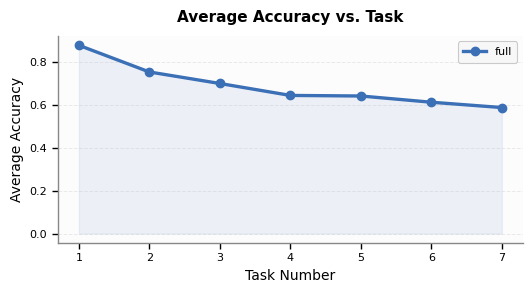

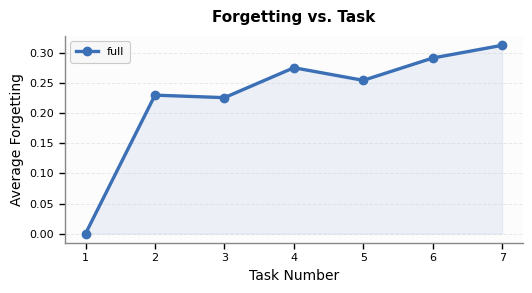

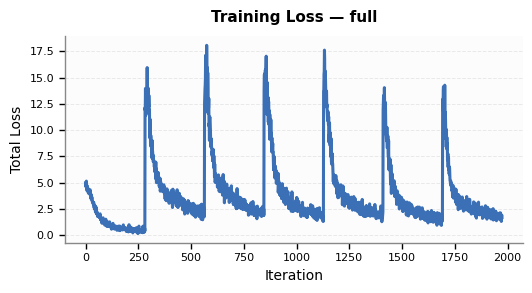

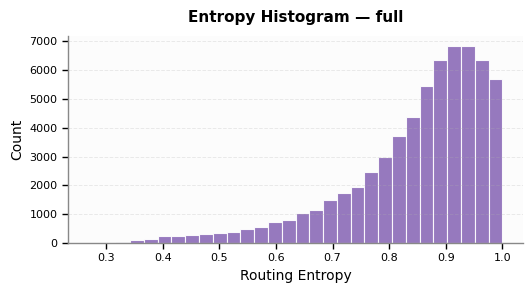

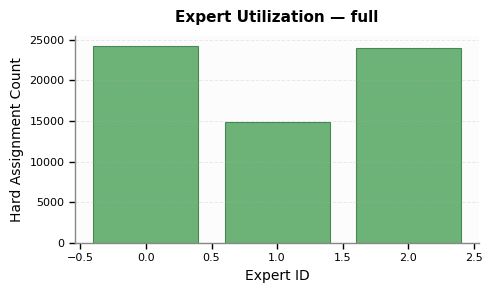

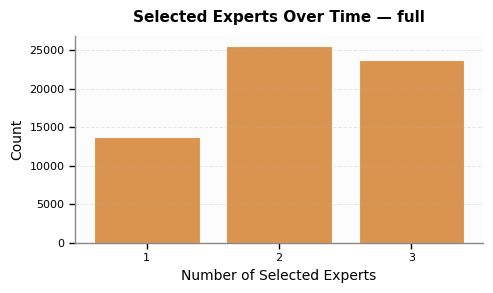

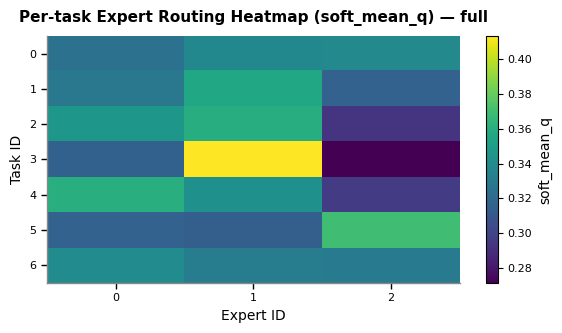

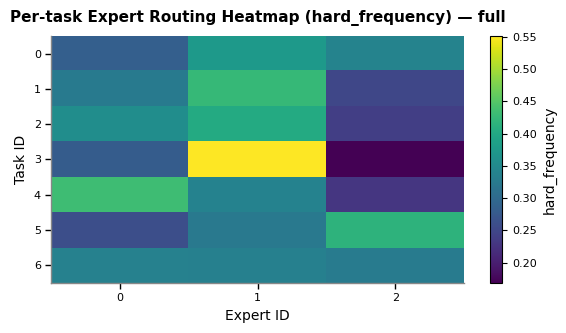

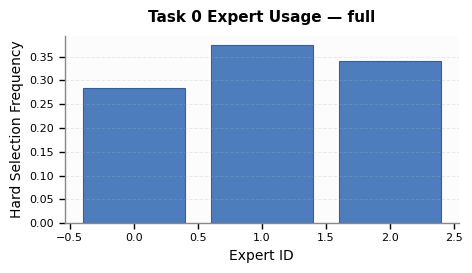

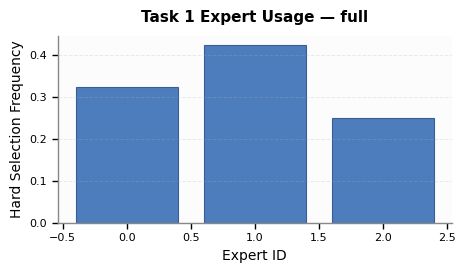

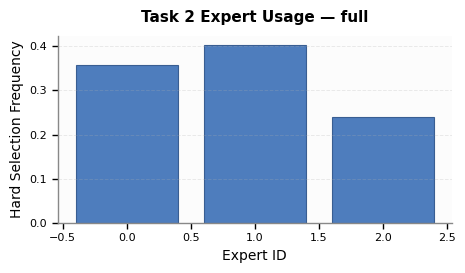

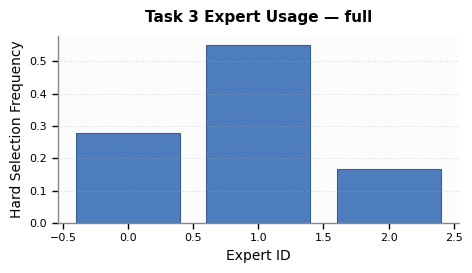

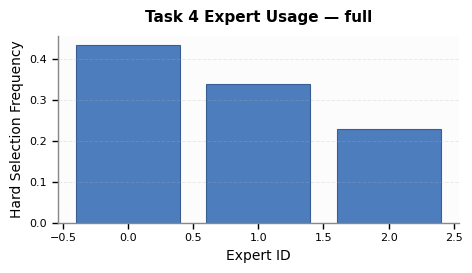

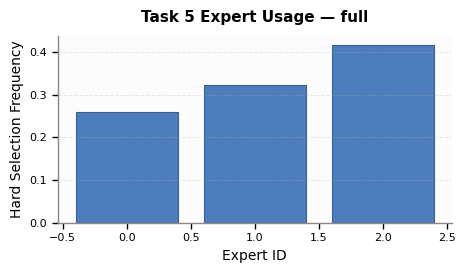

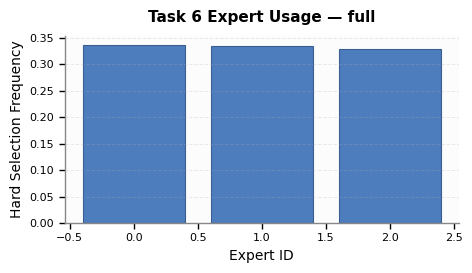

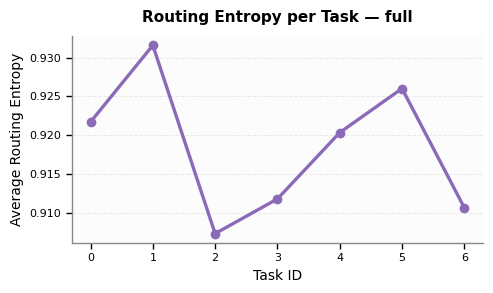

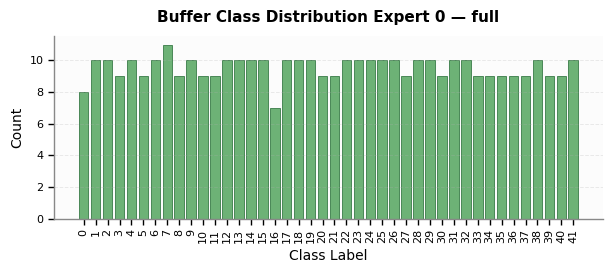

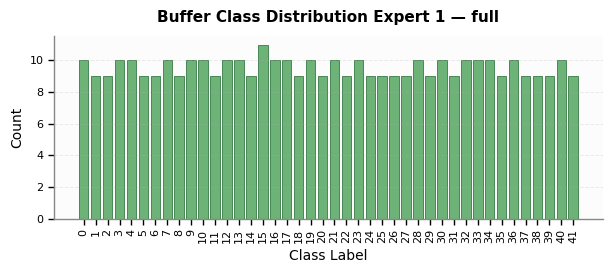

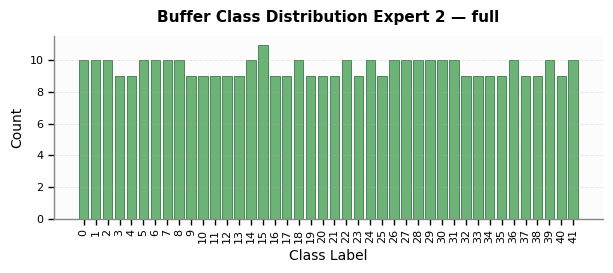

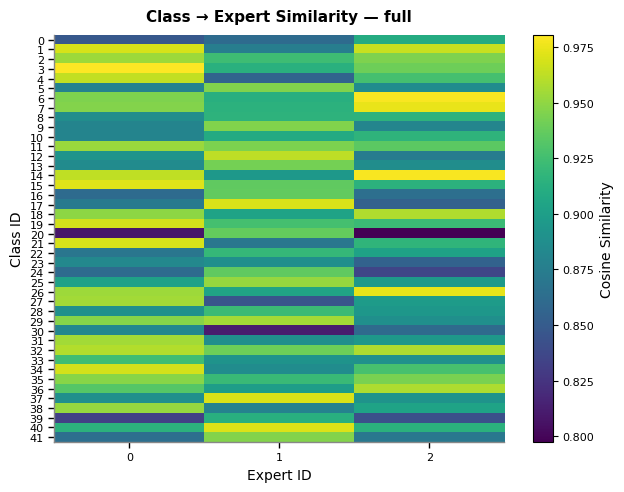

Plots saved to: /content/drive/MyDrive/HomeworksBT/CLMM/clmm_outputs


In [14]:
plot_average_accuracy(all_results, config.out_dir)
plot_forgetting(all_results, config.out_dir)

for name, res in all_results.items():
    plot_training_loss(res, config.out_dir)
    plot_entropy_hist(res, config.out_dir)
    plot_expert_utilization(res, config.out_dir)
    plot_num_selected(res, config.out_dir)
    plot_routing_heatmap(res, config.out_dir, use_soft=True)
    plot_routing_heatmap(res, config.out_dir, use_soft=False)
    plot_per_task_bars(res, config.out_dir)
    plot_entropy_by_task(res, config.out_dir)
    plot_buffer_class_distribution(res, config.out_dir)
    plot_class_expert_heatmap(res["model"], config.out_dir, name)

print("Plots saved to:", config.out_dir)


## 14. Final Summary and Additional Analysis
Prints final metrics, class-expert usage analysis, and the compute-savings comparison against static top-3 routing.

FINAL SUMMARY
Method: full
Accuracy matrix A[k, j]:
[[0.8767    nan    nan    nan    nan    nan    nan]
 [0.6467 0.8583    nan    nan    nan    nan    nan]
 [0.68   0.6033 0.8133    nan    nan    nan    nan]
 [0.5917 0.555  0.575  0.8517    nan    nan    nan]
 [0.55   0.6383 0.585  0.6083 0.8217    nan    nan]
 [0.5467 0.4617 0.5133 0.6183 0.6233 0.9067    nan]
 [0.4267 0.5333 0.4433 0.61   0.5867 0.6517 0.8567]]
Average accuracy by task: [0.8767 0.7525 0.6989 0.6433 0.6407 0.6117 0.5869]
Forgetting by task: [0.     0.23   0.2258 0.2756 0.2546 0.2917 0.3128]
Backward transfer by task: [ 0.     -0.23   -0.2258 -0.2756 -0.2546 -0.2917 -0.3128]
Final average accuracy: 0.5869
Final average forgetting: 0.3128
Final backward transfer: -0.3128
----------------------------------------------------------------------


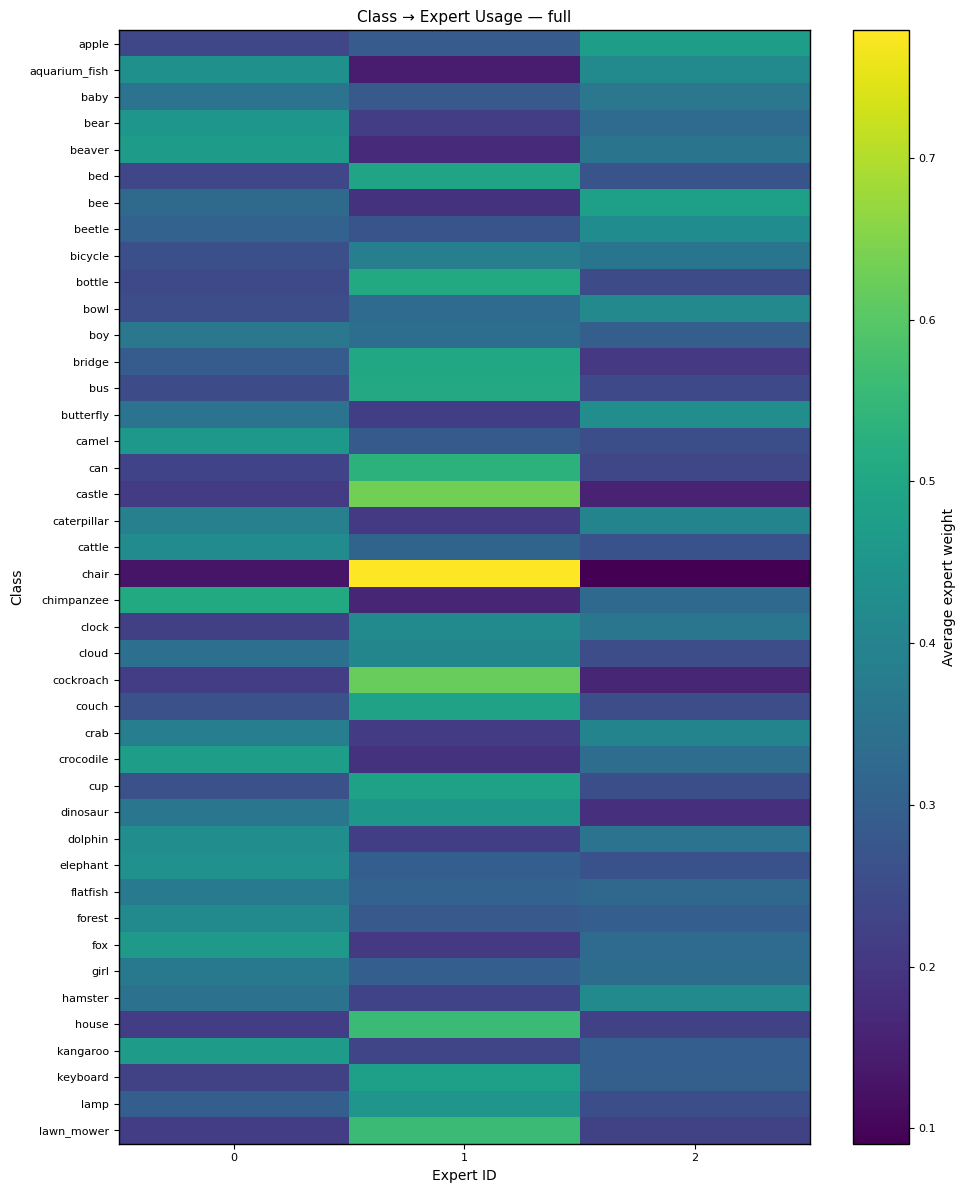

Full avg selected experts: 2.159063492063492
Static top3 avg selected experts: 3.0
Relative expert compute: 0.7196878306878306
Compute saved vs top3: 0.2803121693121694
full         | avg experts/sample=2.159 | relative compute=0.720 | saved vs top3=28.0%


In [15]:
print("FINAL SUMMARY")
print("=" * 70)

for name, res in all_results.items():
    print(f"Method: {name}")
    print("Accuracy matrix A[k, j]:")
    print(np.round(res["acc_matrix"], 4))

    print("Average accuracy by task:", np.round(res["avg_acc"], 4))
    print("Forgetting by task:", np.round(res["forgetting"], 4))
    print("Backward transfer by task:", np.round(res["bwt"], 4))

    print(f"Final average accuracy: {res['final_avg_acc']:.4f}")
    print(f"Final average forgetting: {res['final_forgetting']:.4f}")
    print(f"Final backward transfer: {res['final_bwt']:.4f}")

    print("-" * 70)

@torch.no_grad()
def compute_class_expert_usage(model, dataset, cfg, device):
    """
    Returns:
        class_expert_counts: [num_classes, num_experts]
    """
    model.eval()

    loader = DataLoader(
        dataset,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    num_classes = cfg.num_classes
    num_experts = cfg.num_experts

    counts = torch.zeros(num_classes, num_experts)
    totals = torch.zeros(num_classes)

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        _, _, q = model.route_from_x(x)
        selected, weights, _ = select_experts(q, cfg.routing_mode, cfg)

        selected = selected.cpu()
        weights = weights.cpu()
        y = y.cpu()

        B, S = selected.shape

        for i in range(B):
            c = int(y[i].item())
            totals[c] += 1

            for s in range(S):
                e = int(selected[i, s].item())
                w = float(weights[i, s].item())
                counts[c, e] += w

    # normalize per class
    for c in range(num_classes):
        if totals[c] > 0:
            counts[c] /= totals[c]

    return counts

def plot_class_expert_usage_with_labels(counts, class_names, out_dir, method_name):
    plt.figure(figsize=(10, 12))

    plt.imshow(counts.numpy(), aspect="auto")
    plt.colorbar(label="Average expert weight")

    plt.xlabel("Expert ID")
    plt.ylabel("Class")

    # Show class names instead of indices
    plt.yticks(np.arange(len(class_names)), class_names)

    plt.xticks(np.arange(counts.shape[1]))

    plt.title(f"Class → Expert Usage — {method_name}")

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"class_expert_usage_labels_{method_name}.png"), dpi=200)
    plt.show()

for name, res in all_results.items():
    model = res["model"]
    cfg = res["cfg"]

    full_test = torch.utils.data.ConcatDataset(test_task_datasets)

    counts = compute_class_expert_usage(model, full_test, cfg, device)

    # get correct class names
    all_classes = train_task_datasets[0].base_dataset.classes
    selected_classes = sorted({c for task in tasks_run for c in task})
    class_names_subset = [all_classes[c] for c in selected_classes]

    plot_class_expert_usage_with_labels(
        counts[selected_classes],
        class_names_subset,
        config.out_dir,
        name
    )

full_avg_k = np.mean(all_results["full"]["logs"]["num_selected"])
top3_avg_k = 3.0

compute_ratio = full_avg_k / top3_avg_k
compute_saved = 1.0 - compute_ratio

print("Full avg selected experts:", full_avg_k)
print("Static top3 avg selected experts:", top3_avg_k)
print("Relative expert compute:", compute_ratio)
print("Compute saved vs top3:", compute_saved)

for name, res in all_results.items():
    avg_k = np.mean(res["logs"]["num_selected"])
    compute_ratio = avg_k / 3.0
    saved_vs_top3 = 1.0 - compute_ratio

    print(
        f"{name:12s} | avg experts/sample={avg_k:.3f} | "
        f"relative compute={compute_ratio:.3f} | "
        f"saved vs top3={100*saved_vs_top3:.1f}%"
    )
